# 3. Time Series Analysis:
3.1 Analyze the trend of deal creation over time and its correlation with calls.
3.2 Examine the distribution of deal closure times and the duration of the period from creation to closure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the Deals_clean, Calls_clean files and check the data types.

In [2]:
df_deals = pd.read_pickle("../processed/Deals_clean.pkl")
df_deals.head(3)

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Campaign,SLA,Content,Term,...,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,SLA_status,level_norm
0,5805028000056864695,Ben Hall,NaT,NaN,New Lead,NaN,03.07.23women,NaT,v16,women,...,2024-06-21 15:30:00,NaN,NaN,NaN,NaN,5805028000056849495,NaN,<NA>,Unknown,<NA>
1,5805028000056859489,Ulysses Adams,NaT,NaN,New Lead,NaN,Unknown,NaT,NaN,NaN,...,2024-06-21 15:23:00,6.0,NaN,0.0,2000.0,5805028000056834471,NaN,<NA>,Unknown,<NA>
2,5805028000056832357,Ulysses Adams,2024-06-21,D - Non Target,Lost,Non target,engwien_AT,0 days 00:26:43,b1-at,21_06_2024,...,2024-06-21 00:00:00,NaN,NaN,NaN,NaN,5805028000056854421,NaN,<NA>,10-30 min,<NA>


In [3]:
print("Deals: basic info")
print(df_deals.dtypes)

Deals: basic info
Id                              string
Deal Owner Name                 string
Closing Date            datetime64[ns]
Quality                         object
Stage                           object
Lost Reason                     object
Campaign                        object
SLA                    timedelta64[ns]
Content                         object
Term                            object
Source                          object
Payment Type                    object
Product                         object
Education Type                  object
Created Time            datetime64[ns]
Course duration                float64
Months of study                float64
Initial Amount Paid            float64
Offer Total Amount             float64
Contact Name                    string
City                            object
Level of Deutsch                string
SLA_status                      object
level_norm                      object
dtype: object


In [4]:
df_calls = pd.read_pickle("../processed/Calls_clean.pkl")
df_calls.head(3)

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM
0,5805028000000805001,2023-06-30 08:43:00,John Doe,<NA>,Inbound,171.0,Received,NaN,NaN
1,5805028000000768006,2023-06-30 08:46:00,John Doe,<NA>,Outbound,28.0,Attended Dialled,Completed,0.0
2,5805028000000764027,2023-06-30 08:59:00,John Doe,<NA>,Outbound,24.0,Attended Dialled,Completed,0.0


In [5]:
print("Calls: basic info")
print(df_calls.shape)
print(df_calls.dtypes)

Calls: basic info
(95874, 9)
Id                                    string
Call Start Time               datetime64[ns]
Call Owner Name                       object
CONTACTID                             string
Call Type                             object
Call Duration (in seconds)           float64
Call Status                           object
Outgoing Call Status                  object
Scheduled in CRM                     float64
dtype: object


In [6]:
df_calls["CONTACTID"].isna().sum()

np.int64(3933)

Preparation stage. Merging the tables via merge, having previously filtered rows "Payment Done" from the Deals_clean table as successful.

In [7]:
df_deals_success = df_deals[(df_deals["Stage"] == "Payment Done") & (df_deals["Initial Amount Paid"] > 10)].copy()
print("Successful deals:", df_deals_success.shape[0])

Successful deals: 839


In [8]:
result = df_deals_success.merge(df_calls,left_on="Contact Name",right_on="CONTACTID",how="inner")
result.head(3)

,Id_x,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Campaign,SLA,Content,Term,...,level_norm,Id_y,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM
0,5805028000055502703,Eva Kent,2024-06-18,B - Medium,Payment Done,NaN,performancemax_wide_AT,0 days 14:35:20,_{region_name}_,NaN,...,<NA>,5805028000055471633,2024-06-16 10:36:00,Yara Edwards,5805028000055471387,Outbound,0.0,Unattended Dialled,Completed,0.0
1,5805028000055502703,Eva Kent,2024-06-18,B - Medium,Payment Done,NaN,performancemax_wide_AT,0 days 14:35:20,_{region_name}_,NaN,...,<NA>,5805028000055525504,2024-06-16 10:36:00,Yara Edwards,5805028000055471387,Outbound,0.0,Unattended Dialled,Completed,0.0
2,5805028000055524315,Ben Hall,2024-06-19,A - High,Payment Done,NaN,12.07.2023wide_DE,0 days 00:17:25,bloggersvideo11,wide,...,<NA>,5805028000055460357,2024-06-15 17:20:00,Yara Edwards,5805028000055503302,Outbound,278.0,Attended Dialled,Completed,0.0


Shows how many records in the final dataset remained without a contact after all transformations.

In [9]:
result["CONTACTID"].isna().sum()

np.int64(31464)

In [10]:
result.shape

(42071, 33)

Normalize closing date. Filter calls prior to deal close. Drop duplicates by call start time

In [11]:
result["Closing Date"] = (
    pd.to_datetime(result["Closing Date"], errors="coerce")
    .dt.normalize()   
)
result.shape

(42071, 33)

In [12]:
result = result.loc[
    result["Call Start Time"] <= result["Closing Date"],
    ["Contact Name", "Closing Date", "Call Start Time"]
].copy()
result.shape

(17327, 3)

In [13]:
result = result.drop_duplicates(subset=['Call Start Time'])
result.shape

(7084, 3)

number of calls need to close a deal.

The code creates a column with the deal closing month, groups the data by month, and calculates for each period: the number of closed deals, the average and median number of calls per deal.

In [14]:
calls_per_deal = (result.groupby(["Contact Name", "Closing Date"])["Call Start Time"].count().reset_index(name="calls_count"))
print(calls_per_deal.head(10))
print("Successful deals with calls before close:", calls_per_deal.shape[0])

avg_calls = calls_per_deal["calls_count"].mean()
median_calls = calls_per_deal["calls_count"].median()

print(f"Average number of calls per deal: {avg_calls:.2f}")
print(f"Median number of calls per deal: {median_calls:.0f}")

          Contact Name Closing Date  calls_count
0  5805028000001350049   2023-07-22            2
1  5805028000001404153   2024-01-31           37
2  5805028000001880249   2023-08-31           29
3  5805028000002100030   2023-09-20            8
4  5805028000002150769   2024-01-04           27
5  5805028000002333161   2023-08-17           12
6  5805028000002350048   2024-01-26            9
7  5805028000002719033   2023-09-15            5
8  5805028000002771017   2023-09-21            8
9  5805028000002940571   2023-10-31           11
Successful deals with calls before close: 775
Average number of calls per deal: 6.07
Median number of calls per deal: 5


In [15]:

calls_per_deal["Closing_month"] = (
    calls_per_deal["Closing Date"]
    .dt.to_period("M")
    .dt.to_timestamp()  
)
deals_monthly = (
    calls_per_deal
    .groupby("Closing_month")
    .agg(
        deals_count=("calls_count", "size"),
        avg_calls_per_deal=("calls_count", "mean"),
        median_calls_per_deal=("calls_count", "median"),
        total_calls_per_deal=("calls_count", "sum") 
    )
    .reset_index()
)
deals_monthly

,Closing_month,deals_count,avg_calls_per_deal,median_calls_per_deal,total_calls_per_deal
0,2023-07-01,1,2.000000,2.0,2
1,2023-08-01,25,8.040000,4.0,201
2,2023-09-01,26,6.384615,4.5,166
3,2023-10-01,48,5.125000,4.0,246
4,2023-11-01,78,4.666667,3.0,364
5,2023-12-01,87,4.965517,4.0,432
6,2024-01-01,91,6.252747,4.0,569
7,2024-02-01,77,6.051948,4.0,466
8,2024-03-01,95,6.621053,5.0,629
9,2024-04-01,99,6.838384,5.0,677


In [16]:
deals_monthly.to_parquet("../processed/parquet/3_deals_monthly.parquet", index=False)

Conclusion

The volume of closed deals grew from 1 in July 2023 to a peak of 99 deals in April 2024, followed by a decline to 62 deals in June 2024.
Meanwhile, the average and median number of calls per deal stabilized after the initial period: from 2.0 calls in July 2023 (based on a single deal), the metric rose to 5–7 calls in subsequent months. In June 2024, the median increased to 6.5 calls, with an average of 7.4.
This indicates that after the scaling phase, the sales process has stabilized: closing a deal now typically requires 4–7 contacts. The slight increase in metrics in mid-2024 may signal a more complex sales funnel or changes in lead quality — further analysis is recommended.

Creating a visualization with groups by number of calls. The graph shows the number of calls required to close a deal. 

<Figure size 1000x500 with 0 Axes>

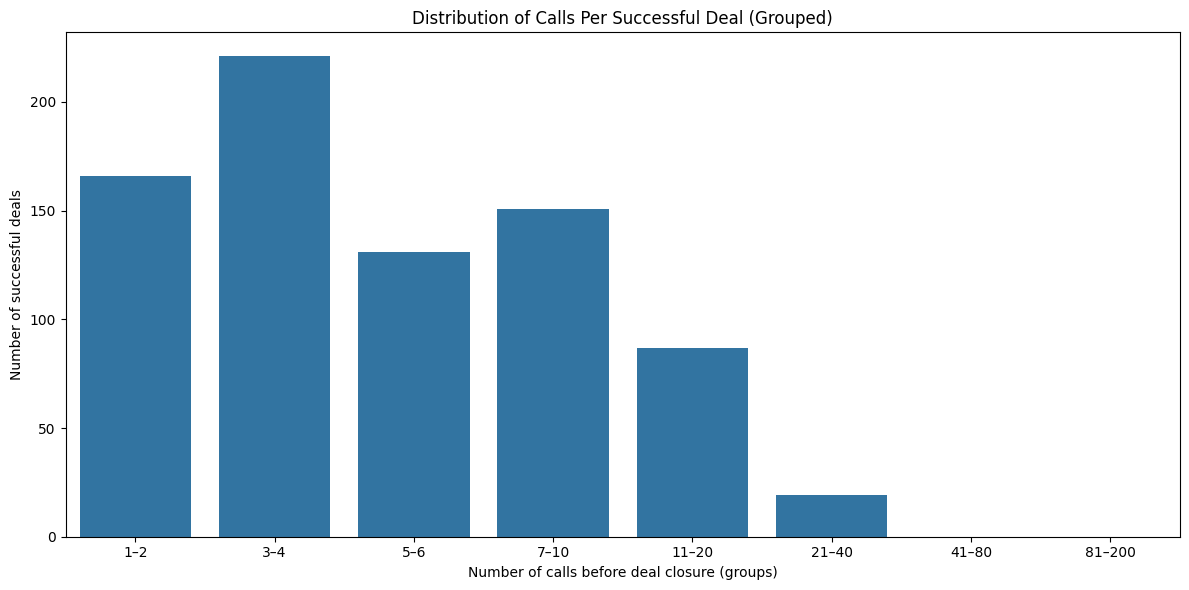

In [17]:
plt.figure(figsize=(10, 5))
bins = [0, 2, 4, 6, 10, 20, 40, 80, 200]
labels = ["1–2", "3–4", "5–6", "7–10", "11–20", "21–40", "41–80", "81–200"]

calls_per_deal["calls_group"] = pd.cut(
    calls_per_deal["calls_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
plt.figure(figsize=(12, 6))
sns.countplot(
    data=calls_per_deal,
    x="calls_group"
)
plt.title("Distribution of Calls Per Successful Deal (Grouped)")
plt.xlabel("Number of calls before deal closure (groups)")
plt.ylabel("Number of successful deals")
plt.tight_layout()
plt.show()

The code prepares data for plotting two charts on a single canvas: the trend of successful deals and the median number of calls per deal over time.
(A Closing_month column is created — the deal closing date converted to the first day of the month (for grouping).
Data is aggregated by month: counting closed deals (deals_count) and calculating the median number of calls per deal (median_calls_per_deal).
A string representation of the month (Closing_month_str) in YYYY-MM format is added for clear X-axis labeling.
The resulting DataFrame is printed for verification)

In [18]:
plt.figure(figsize=(10, 5))
calls_per_deal["Closing_month"] = (
    calls_per_deal["Closing Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)
deals_monthly = (
    calls_per_deal
    .groupby("Closing_month")
    .agg(
        deals_count=("calls_count", "size"),
        median_calls_per_deal=("calls_count", "median"),
        total_calls_per_deal=("calls_count", "sum")
    )
    .reset_index()
)
deals_monthly["Closing_month_str"] = deals_monthly["Closing_month"].dt.strftime("%Y-%m")
deals_monthly

,Closing_month,deals_count,median_calls_per_deal,total_calls_per_deal,Closing_month_str
0,2023-07-01,1,2.0,2,2023-07
1,2023-08-01,25,4.0,201,2023-08
2,2023-09-01,26,4.5,166,2023-09
3,2023-10-01,48,4.0,246,2023-10
4,2023-11-01,78,3.0,364,2023-11
5,2023-12-01,87,4.0,432,2023-12
6,2024-01-01,91,4.0,569,2024-01
7,2024-02-01,77,4.0,466,2024-02
8,2024-03-01,95,5.0,629,2024-03
9,2024-04-01,99,5.0,677,2024-04


<Figure size 1000x500 with 0 Axes>

In [19]:
print(deals_monthly['Closing_month'].min())
print(deals_monthly['Closing_month'].max())

2023-07-01 00:00:00
2024-06-01 00:00:00


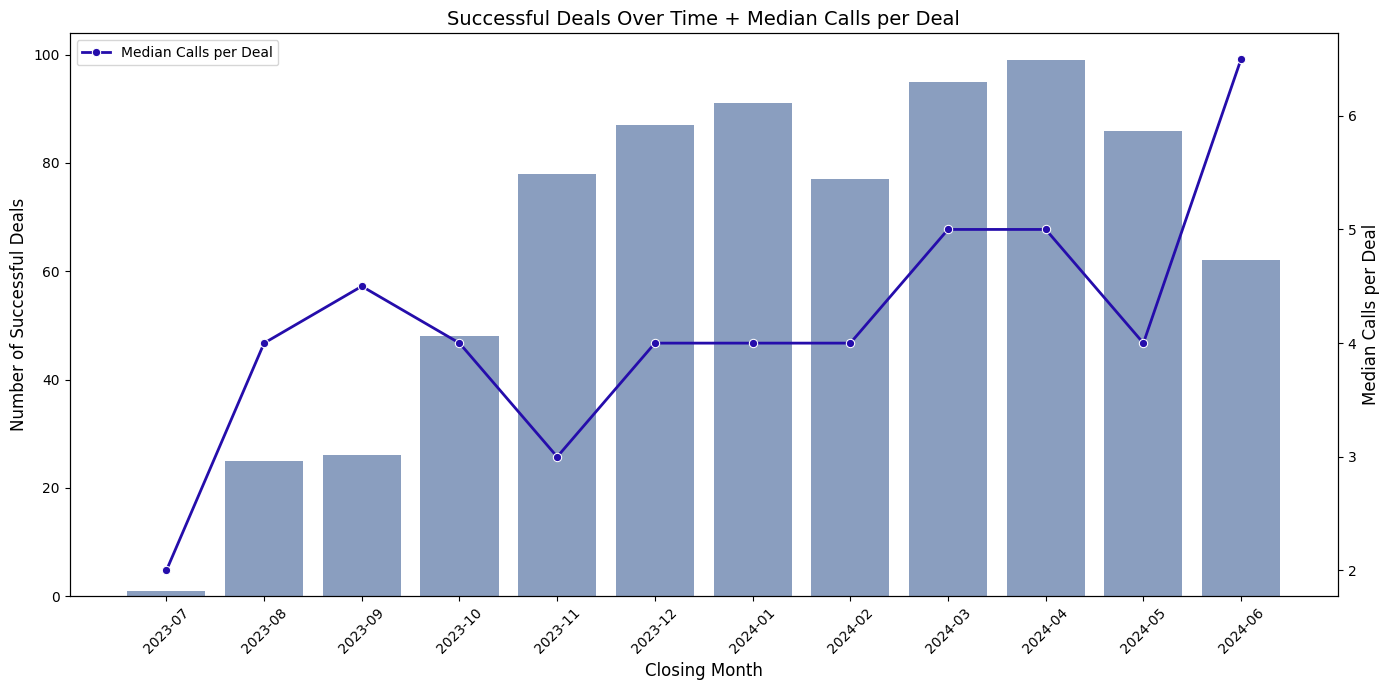

In [20]:
plt.figure(figsize=(14, 7))
ax1 = sns.barplot(data=deals_monthly,x="Closing_month_str",y="deals_count",color="#4C72B0",alpha=0.7)

ax1.set_xlabel("Closing Month", fontsize=12)
ax1.set_ylabel("Number of Successful Deals", fontsize=12)
ax1.set_title("Successful Deals Over Time + Median Calls per Deal", fontsize=14)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=deals_monthly,x="Closing_month_str",y="median_calls_per_deal",marker="o",linewidth=2,color="#250DAB",ax=ax2,
    label="Median Calls per Deal")

ax2.set_ylabel("Median Calls per Deal", fontsize=12)
ax2.grid(False)

lines_labels = ax2.get_legend_handles_labels()
ax2.legend(lines_labels[0], lines_labels[1], loc="upper left")

plt.tight_layout()
plt.show()

The number of successful deals fluctuates over time, with clear periods of growth and decline—suggesting seasonality or shifts in market demand.
The median number of calls per deal does not directly follow the trend in deal volume, indicating that call quantity alone does not drive sales success.
In months with the highest deal closures, the median call count often remains low—signaling high process efficiency: less effort, greater output.
When the median number of calls rises while deal volume falls, it signals declining efficiency: the team invests more effort for weaker results.
More calls ≠ more deals. Success hinges on quality, not just quantity. The team should shift focus from "how many calls we make" to "who we call and how"—that's what drives sustainable results.

3.2. Calculate the deal closure time (time_to_close) for successful contracts — the number of days between creation date and closing date. Distribution Visualization for time_to_close.

Conclusion ( presentation)
Both charts show that most deals close quickly and with a low number of calls.
A small share of "long" or "difficult" deals creates a right-skewed tail.
time_to_close has higher variability because it depends on the client, whereas calls_count is more controllable by the sales team.

In [21]:
df_deals_success["time_to_close"] = (
    df_deals_success["Closing Date"] - df_deals_success["Created Time"]
).dt.days

In [22]:
df_deals_success["time_to_close"].describe()

count    839.000000
mean      25.342074
std       35.121182
min        0.000000
25%       11.000000
50%       14.000000
75%       23.500000
max      304.000000
Name: time_to_close, dtype: float64

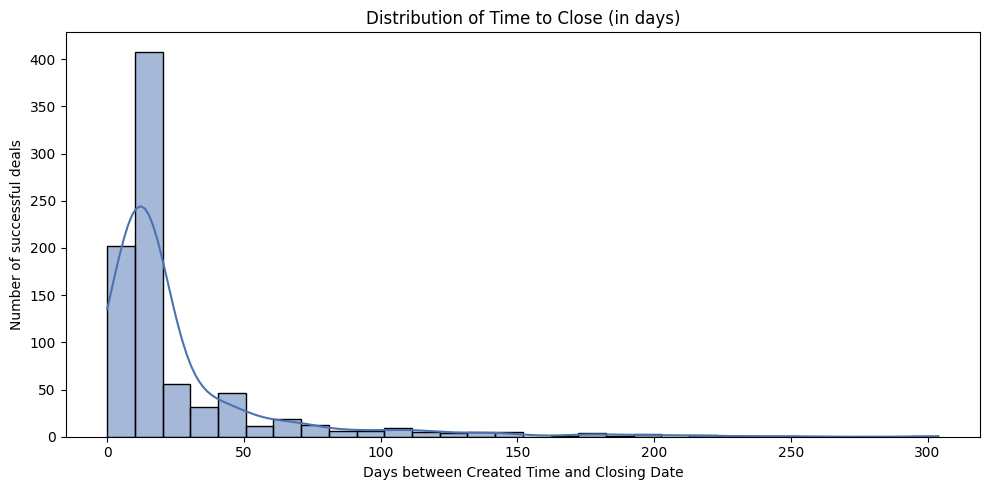

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(
    df_deals_success["time_to_close"],
    bins=30,
    kde=True,
    color="#4C72B0"
)
plt.title("Distribution of Time to Close (in days)")
plt.xlabel("Days between Created Time and Closing Date")
plt.ylabel("Number of successful deals")
plt.tight_layout()
plt.show()

Conclusion. 

for time_to_close Distribution Chart
The chart shows a right-skewed distribution:
Most deals close quickly — the histogram peak is in the 10–15 days range (median = 14 days).
A long right tail indicates "slow" outlier deals (up to 304 days) that inflate the mean (25 days) but don't represent the typical case.
High variability (std = 35 days) suggests process inconsistency: closure time heavily depends on deal-specific factors.

Number of Calls Needed for a Deal to Close

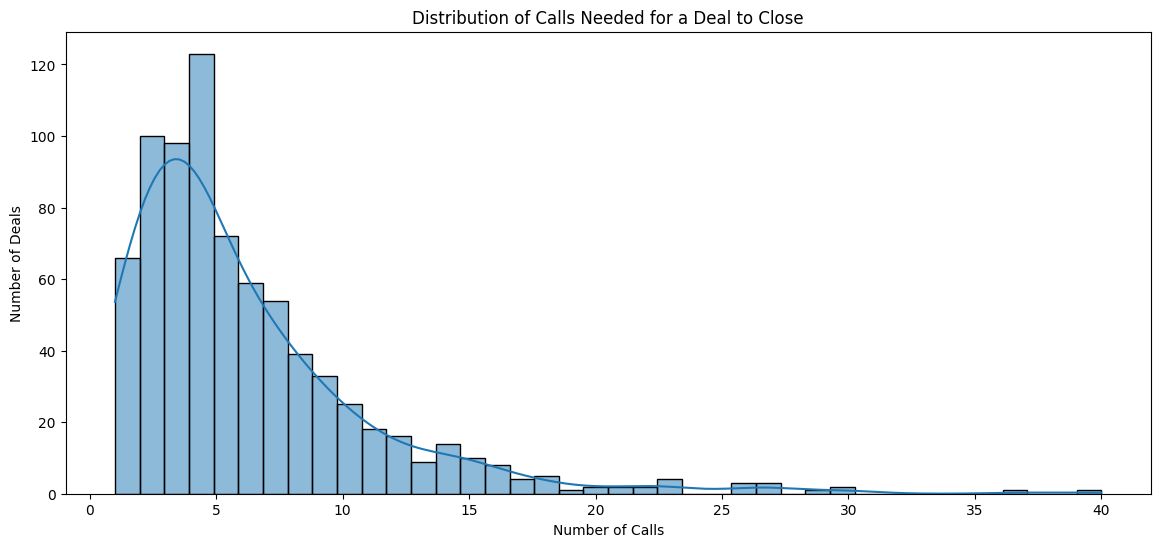

In [24]:
plt.figure(figsize=(14,6))
sns.histplot(calls_per_deal["calls_count"], bins=40, kde=True)
plt.title("Distribution of Calls Needed for a Deal to Close")
plt.xlabel("Number of Calls")
plt.ylabel("Number of Deals")
plt.grid(False)
plt.show()

Conclusion 
Both charts show a right-skewed distribution:
Most successful deals close after 5–20 calls — this is the "working range" for a typical scenario.
The peak is in the 7–10 calls group, indicating the optimal contact frequency for conversion.
A long right tail (40–200 calls) represents deals requiring disproportionately high effort — likely complex enterprise clients, repeated attempts, or low-quality leads.
Practical Recommendation:
Focus on optimizing the process for the ≤20 calls range — it covers ~80% of successful deals. Deals in the tail (>40 calls) warrant separate analysis: they may be better qualified earlier or routed to a specialized team.